In [1]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

file_path = "new_dAtA/cmems_GEBCO_resampled_new.nc"

try:
    ds_combined = xr.open_dataset(file_path)
except FileNotFoundError:
    print(f"Error: The file was not found at '{file_path}'")
    print("Please make sure the file path is correct.")
    exit()


lat = ds_combined['latitude'].values
lon = ds_combined['longitude'].values
depth = ds_combined['deptho'].values


lon_grid, lat_grid = np.meshgrid(lon, lat)

# if 'mask' in ds_combined:
#     mask = ds_combined['mask'].values
#     # Ensure mask has the same dimensions as depth before applying
#     if mask.shape == depth.shape:
#         depth = np.where(mask == 1, depth, np.nan)
#     else:
#         print("Warning: Mask shape does not match depth shape. Mask will not be applied.")

surface_trace = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=-depth,
    colorscale='inferno',
    connectgaps=False,  # Important for handling the land mask (NaNs)
    colorbar=dict(
        title='Depth (m)',
        len=0.75,
        x=0.85
    )
)
fig = go.Figure(data=[surface_trace])
fig.update_layout(
    height=800,
    width=1600,
    title={
        'text': 'Combined Depth',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        # Set aspect ratio to make the plot look more natural
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    margin=dict(l=40, r=40, b=40, t=80) # Adjust margins
)

fig.show()

In [17]:
from netCDF4 import Dataset
all_ds = Dataset(r'new_dAtA/after_xl.nc')
all_ds1= Dataset(r'new_dAtA/till xl.nc')
ds3 = Dataset(r'new_dAtA/tla_taux_tauy.nc')
print(all_ds.variables.keys())
print(all_ds1.variables.keys())
print(ds3.variables.keys())

dict_keys(['VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK', 'latitude', 'longitude', 'time'])
dict_keys(['VMDR_SW1', 'VCMX', 'VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL', 'latitude', 'longitude', 'time'])
dict_keys(['TAUX', 'TAUY', 'TLA', 'latitude', 'longitude', 'time'])


In [3]:
import numpy as np

variable_data = all_ds1.variables['VMXL'][:]  # Load the data as a NumPy array

# Find the maximum value
max_value = np.max(variable_data)

# Find the index (multi-dimensional) of the maximum value
max_index = np.unravel_index(np.argmax(variable_data), variable_data.shape)
print("Max wave height",max_value)
print(max_index)

Max wave height 14.439999677240849
(np.int64(33690), np.int64(151), np.int64(18))


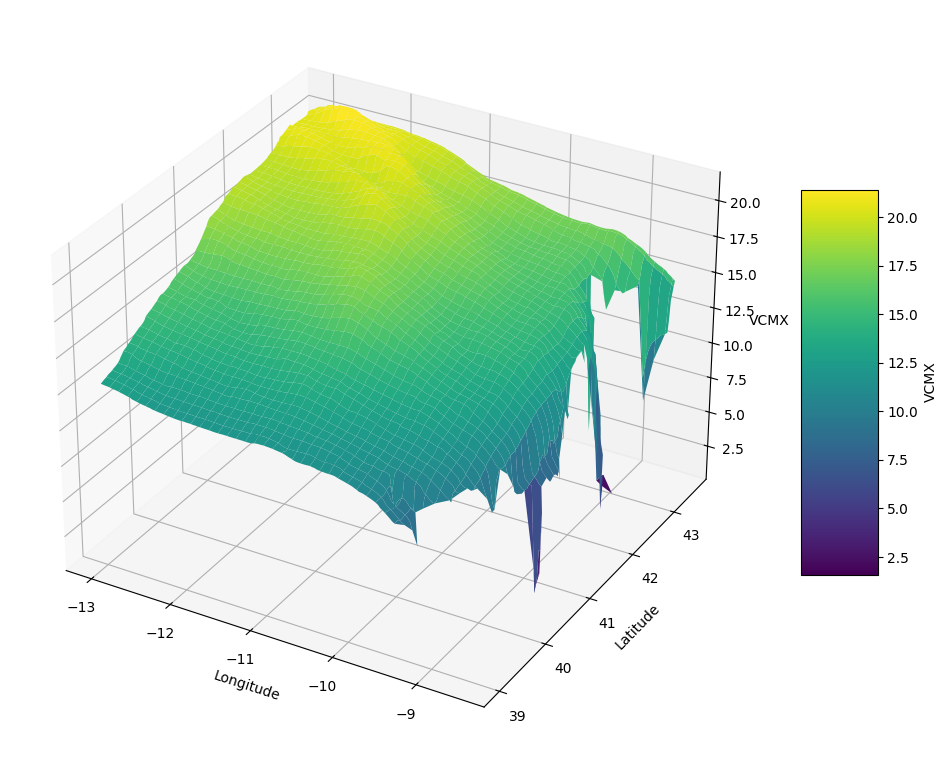

In [4]:
from mpl_toolkits.mplot3d import axis3d
import matplotlib.pyplot as plt

lat = all_ds1.variables['latitude'][:]
lon = all_ds1.variables['longitude'][:]
vcmx = all_ds1.variables['VCMX'][:]

Lat, Lon = np.meshgrid(lon,lat)
Lat.shape

fig = plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')

# ax.view_init(roll=0, azim=0)

# lat = all_ds.variables['latitude'][:]
# lon = all_ds.variables['longitude'][:]
# vcmx = all_ds.variables['VCMX'][:]

# Lat, Lon = np.meshgrid(lat,lon)

surf = ax.plot_surface(Lat ,Lon,vcmx[33690,:,:],cmap='viridis',  edgecolor='none')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('VCMX')
fig.colorbar(surf, shrink=0.5, aspect=5, label='VCMX')

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Select time index
# -------------------------------
t = 33690
vped = all_ds.variables['VPED'][:]
vmdr = all_ds1.variables['VMDR'][:]


vp_dir = vped[t, :, :]   # direction in degrees
vm_dir = vmdr[t, :, :]   # direction in degrees

# -------------------------------
# Create lat/lon mesh
# -------------------------------
Lon, Lat = np.meshgrid(lon, lat)

# -------------------------------
# Convert direction → vector components
# Direction FROM north, clockwise
# -------------------------------
theta = np.deg2rad(vp_dir)

u = -np.sin(theta)   # x-component (longitude)
v = -np.cos(theta)   # y-component (latitude)

# -------------------------------
# Reduce arrow density
# -------------------------------
skip = 3

# -------------------------------
# Plot quiver
# -------------------------------
plt.figure(figsize=(12, 10))

plt.quiver(
    Lon[::skip, ::skip],
    Lat[::skip, ::skip],
    u[::skip, ::skip],
    v[::skip, ::skip],
    scale=40,
    width=0.002,
    headwidth=3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("VMDR Direction (Quiver Plot)")

plt.axis("equal")
plt.grid(True)
plt.show()

: 

In [3]:
import numpy as np
import plotly.graph_objects as go
from netCDF4 import Dataset
import xarray as xr

all_ds = Dataset(r'new_dAtA/after_xl.nc')
all_ds1= Dataset(r'new_dAtA/till xl.nc')
ds3 = Dataset(r'new_dAtA/tla_taux_tauy.nc')

ds_bathy = Dataset(r'new_dAtA/cmems_GEBCO_resampled_new.nc')
ds_mask  = xr.open_dataset("new_dAtA/mask_deptho copy.nc")

t = 33694
tn = 33693

lat_b = ds_bathy.variables['latitude'][:]
lon_b = ds_bathy.variables['longitude'][:]
depth = ds_bathy.variables['deptho'][:]

lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# -------------------------------------------------
# Model grid
# -------------------------------------------------
lat = all_ds.variables['latitude'][:]
lon = all_ds.variables['longitude'][:]

lon_grid, lat_grid = np.meshgrid(lon, lat)

# -------------------------------------------------
# Extract variables (NO .values)
# -------------------------------------------------
vcmx = all_ds1.variables['VCMX'][t, :, :]
tla  = ds3.variables['TLA'][tn, :, :].data

mask = ds_mask['mask'].values   # <-- if error, print(ds_mask)

# Convert masked arrays → NaN (important for Plotly)
vcmx = np.where(mask == 1, vcmx, np.nan)
tla  = np.where(mask == 1, tla, np.nan)

# -------------------------------------------------
# Vertical offsets
# -------------------------------------------------
z_offset_vcmx = np.nanmax(depth) * 0.02
z_offset_tla  = np.nanmax(depth) * 0.05

# -------------------------------------------------
# Bathymetry surface
# -------------------------------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(title='Depth (m)', x=0.80),
    name='Bathymetry'
)

# -------------------------------------------------
# VCMX surface
# -------------------------------------------------
vcmx_surface = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=vcmx + z_offset_vcmx,
    surfacecolor=vcmx,
    colorscale='Viridis',
    opacity=0.85,
    showscale=True,
    connectgaps=False,
    colorbar=dict(title='VCMX', x=0.88),
    name='VCMX'
)

# -------------------------------------------------
# TLA surface
# -------------------------------------------------
tla_surface = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=tla + z_offset_tla ,
    surfacecolor=tla,
    colorscale='turbid',
    opacity=0.85,
    showscale=True,
    connectgaps=False,
    colorbar=dict(title='TLA', x=0.96),
    name='TLA'
)

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig = go.Figure(
    data=[
        bathy_surface,
        vcmx_surface,
        tla_surface
    ]
)

fig.update_layout(
    title=dict(
        text='3D Bathymetry with VCMX and TLA',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / Variable Value',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=900,
    width=1700,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()

In [24]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

# ---------------------------
# Load datasets
# ---------------------------
ds_bathy = xr.open_dataset("dAtA/cmems_GEBCO_resampled1.nc")
ds_model = all_ds  # already loaded wave/model dataset
ds_mask  = xr.open_dataset(
    "dAtA/cmems_mod_ibi_wav_my_0.027deg_static_1756186965833.nc"
)

# ---------------------------
# Bathymetry
# ---------------------------
lat_b = ds_bathy['latitude'].values
lon_b = ds_bathy['longitude'].values
depth = ds_bathy['deptho'].values

lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# ---------------------------
# VCMX (single timestep)
# ---------------------------
t = 33694

lat_m = ds_model['latitude'][:]
lon_m = ds_model['longitude'][:]
vcmx = ds_model['VCMX'][t, :, :]

lon_m_grid, lat_m_grid = np.meshgrid(lon_m, lat_m)

# ---------------------------
# Load mask (CHANGE variable name here if needed)
# ---------------------------
mask = ds_mask['mask'].values   # <-- if error, print(ds_mask)

# ---------------------------
# Apply mask to VCMX
# ---------------------------
# Mask land points → NaN
vcmx_masked = np.where(mask == 1, vcmx, np.nan)

# ---------------------------
# Surface 1: Bathymetry
# ---------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(
        title='Depth (m)',
        x=0.85
    ),
    name='Bathymetry'
)

# ---------------------------
# Surface 2: Masked VCMX
# ---------------------------
# Vertical offset so it sits above seabed
z_offset = np.nanmax(depth) * 0.02

vcmx_surface = go.Surface(
    x=lon_m_grid,
    y=lat_m_grid,
    z=vcmx_masked + z_offset,
    surfacecolor=vcmx_masked,
    colorscale='Viridis',
    opacity=0.9,
    showscale=True,
    colorbar=dict(
        title='VCMX',
        x=0.95
    ),
    connectgaps=False,  # IMPORTANT for masked NaNs
    name='VCMX (masked)'
)

# ---------------------------
# Create figure
# ---------------------------
fig = go.Figure(data=[bathy_surface, vcmx_surface])

fig.update_layout(
    title=dict(
        text='3D Interactive Bathymetry + Masked VCMX',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / VCMX',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=850,
    width=1600,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()


In [10]:
# import xarray as xr
# import numpy as np
# import plotly.graph_objects as go


# # ds3 = Dataset(r'new_dAtA/tla_taux_tauy.nc')


# # ---------------------------
# # Load datasets
# # ---------------------------
# ds_bathy = xr.open_dataset("new_dAtA/cmems_GEBCO_resampled_new.nc")
# ds_model = xr.open_dataset("new_dAtA/after_xl.nc")   # your wave model dataset (VPED)
# ds1_model = xr.open_dataset("new_dAtA/till xl.nc")   # your wave model dataset (VCMX)
# ds_mask  = xr.open_dataset("new_dAtA/mask_deptho copy.nc")

import xarray as xr
import numpy as np
import plotly.graph_objects as go
from netCDF4 import Dataset

# ---------------------------
# Load datasets
# ---------------------------

all_ds = Dataset(r'new_dAtA/after_xl.nc')
all_ds1= Dataset(r'new_dAtA/till xl.nc')    
ds_bathy = xr.open_dataset("new_dAtA/cmems_GEBCO_resampled_new.nc")
ds_model = all_ds   # your wave model dataset (VCMX, VPED)
ds_mask  = xr.open_dataset("new_dAtA/mask_deptho copy.nc")

# ---------------------------
# Bathymetry
# ---------------------------
lat_b = ds_bathy['latitude'].values
lon_b = ds_bathy['longitude'].values
depth = ds_bathy['deptho'].values
lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# ---------------------------
# VCMX (single timestep)
# ---------------------------
t = 33690
lat_m = ds_model['latitude'][:]
lon_m = ds_model['longitude'][:]
vcmx = all_ds1['VCMX'][t, :, :]

# ---------------------------
# Apply mask
# ---------------------------
mask = ds_mask['mask'].values   # 1=sea, 0=land
vcmx_masked = np.where(mask == 1, vcmx, np.nan)

lon_m_grid, lat_m_grid = np.meshgrid(lon_m, lat_m)

# ---------------------------
# VPED / VMDR vectors
# ---------------------------
vp_dir = ds_model['VPED'][t, :, :]   # degrees
theta = np.deg2rad(vp_dir)
u = -np.sin(theta)
v = -np.cos(theta)
w = np.zeros_like(u)   # horizontal arrows

# Downsample for clarity
skip = 5
Lon_s = lon_m_grid[::skip, ::skip]
Lat_s = lat_m_grid[::skip, ::skip]
u_s = u[::skip, ::skip]
v_s = v[::skip, ::skip]
w_s = w[::skip, ::skip]
z_s = vcmx_masked[::skip, ::skip] + np.nanmax(vcmx_masked)*0.05  # offset above VCMX

# ---------------------------
# Bathymetry surface
# ---------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(title='Depth (m)', x=0.85),
    name='Bathymetry'
)

# ---------------------------
# VCMX surface
# ---------------------------
vcmx_surface = go.Surface(
    x=lon_m_grid,
    y=lat_m_grid,
    z=vcmx_masked,
    surfacecolor=vcmx_masked,
    colorscale='Viridis',
    opacity=0.9,
    showscale=True,
    colorbar=dict(title='VCMX', x=0.95),
    connectgaps=False,
    name='VCMX (masked)'
)

# ---------------------------
# VPED vectors as cones
# ---------------------------
cone_trace = go.Cone(
    x=Lon_s.flatten(),
    y=Lat_s.flatten(),
    z=z_s.flatten(),
    u=u_s.flatten(),
    v=v_s.flatten(),
    w=w_s.flatten(),
    colorscale='Blues',
    sizemode='scaled',
    sizeref=0.5,
    anchor='tail',
    showscale=False,
    name='VPED Direction'
)

# ---------------------------
# Combine all in one figure
# ---------------------------
fig = go.Figure(data=[bathy_surface, vcmx_surface, cone_trace])

fig.update_layout(
    title=dict(text='3D Bathymetry + Masked VCMX + VPED Vectors', x=0.5),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / VCMX',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=850,
    width=1600,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()
